In [3]:
import pandas as pd
df=pd.read_csv('ABC Company.csv')
print(df.head())

            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25  06-Feb     180   
1    Jae Crowder  Boston Celtics      99       SF   25  06-Jun     235   
2   John Holland  Boston Celtics      30       SG   27  06-May     205   
3    R.J. Hunter  Boston Celtics      28       SG   22  06-May     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29  06-Oct     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


In [4]:
print(df.isnull().sum())

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64


In [5]:
df['College']=df['College'].fillna(df['College'].mode()[0])

In [6]:
df['Salary']=df['Salary'].fillna(df['Salary'].mean())

In [7]:
print(df.isnull().sum())

Name        0
Team        0
Number      0
Position    0
Age         0
Height      0
Weight      0
College     0
Salary      0
dtype: int64


In [8]:
#Replacing height values 
from random import randint 
h=[]
for i in range(len(df)):
    h.append(randint(150,180))
df['Height']=h
    
    

In [9]:
print(df.head())

            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25     163     180   
1    Jae Crowder  Boston Celtics      99       SF   25     175     235   
2   John Holland  Boston Celtics      30       SG   27     177     205   
3    R.J. Hunter  Boston Celtics      28       SG   22     157     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29     152     231   

             College        Salary  
0              Texas  7.730337e+06  
1          Marquette  6.796117e+06  
2  Boston University  4.833970e+06  
3      Georgia State  1.148640e+06  
4           Kentucky  5.000000e+06  


In [10]:
df['Salary']=df['Salary'].fillna(df['Salary'].median())

In [11]:
df['Salary'] = df['Salary'].astype(int)

In [12]:
gdf=df['Name'].groupby (df['Team']).count()
percentage=(gdf/gdf.sum())*100
r=pd.DataFrame({'Team':gdf.index,'Count':gdf.values,'Percentage':percentage.values})
print(r)

                      Team  Count  Percentage
0            Atlanta Hawks     15    3.275109
1           Boston Celtics     15    3.275109
2            Brooklyn Nets     15    3.275109
3        Charlotte Hornets     15    3.275109
4            Chicago Bulls     15    3.275109
5      Cleveland Cavaliers     15    3.275109
6         Dallas Mavericks     15    3.275109
7           Denver Nuggets     15    3.275109
8          Detroit Pistons     15    3.275109
9    Golden State Warriors     15    3.275109
10         Houston Rockets     15    3.275109
11          Indiana Pacers     15    3.275109
12    Los Angeles Clippers     15    3.275109
13      Los Angeles Lakers     15    3.275109
14       Memphis Grizzlies     18    3.930131
15              Miami Heat     15    3.275109
16         Milwaukee Bucks     16    3.493450
17  Minnesota Timberwolves     14    3.056769
18    New Orleans Pelicans     19    4.148472
19         New York Knicks     16    3.493450
20   Oklahoma City Thunder     15 

In [13]:
df['Name'].groupby(df['Position']).count()

Position
C      79
PF    100
PG     92
SF     85
SG    102
Name: Name, dtype: int64

In [15]:
#predominant age g
p=df['Age'].groupby(df['Age']).count()
print(p.idxmax())
#predominant age group
bins = [18, 25, 30, 35, 40, 45, 50]
labels = ['18-25', '26-30', '31-35', '36-40', '41-45', '46-50']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
p = df['Age Group'].value_counts()
print("Predominant Age Group:", p.idxmax())

24
Predominant Age Group: 18-25


In [64]:
#Discover which team and position have the highest salary expenditure.
gdf = df.groupby(['Team', 'Position'])['Salary'].sum()
print(gdf.idxmax())   
print(gdf.max())     

('Los Angeles Lakers', 'SF')
31866445


In [65]:
#Investigate if there's any correlation between age and salary, 
correlation = df['Age'].corr(df['Salary'])
print(correlation)

0.21116954871839147


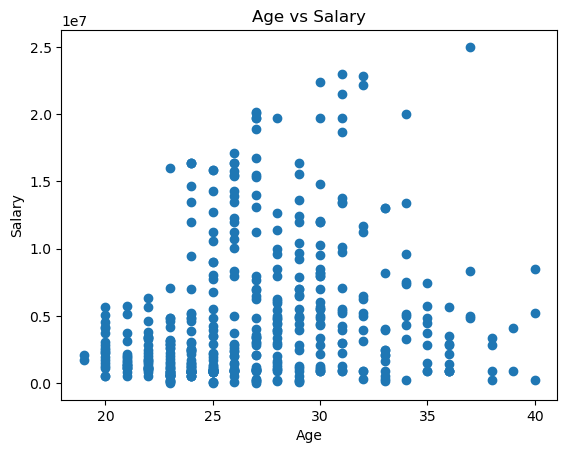

In [66]:
#and represent it visually
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.show()

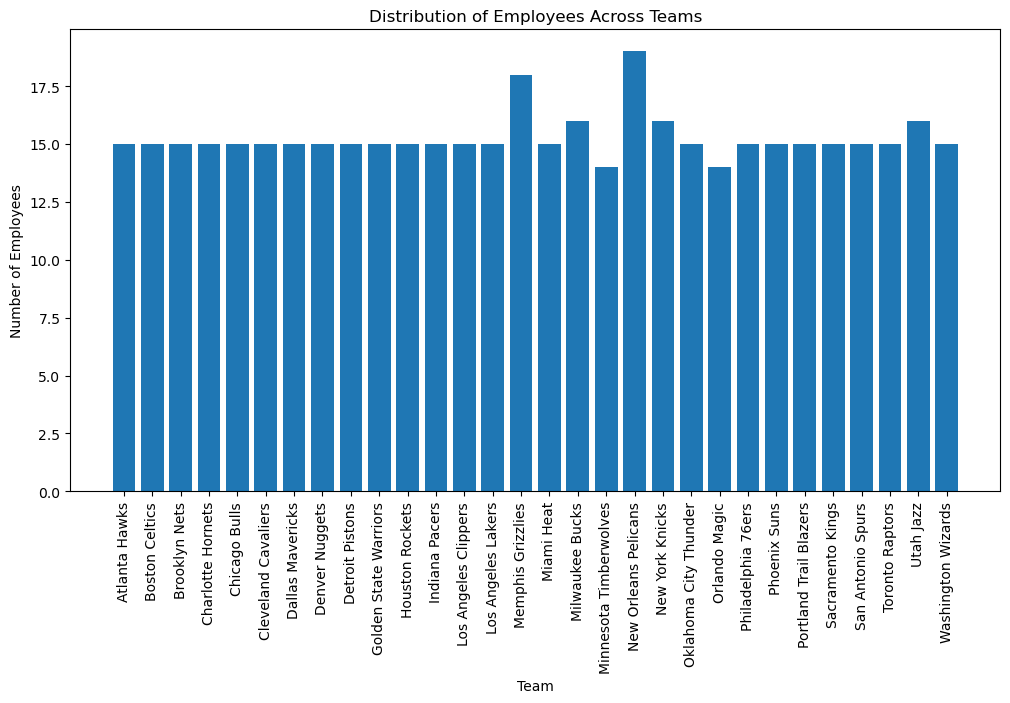

In [18]:
#1. Distribution of employees across each team
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(r['Team'], r['Count'])

plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")


plt.show()

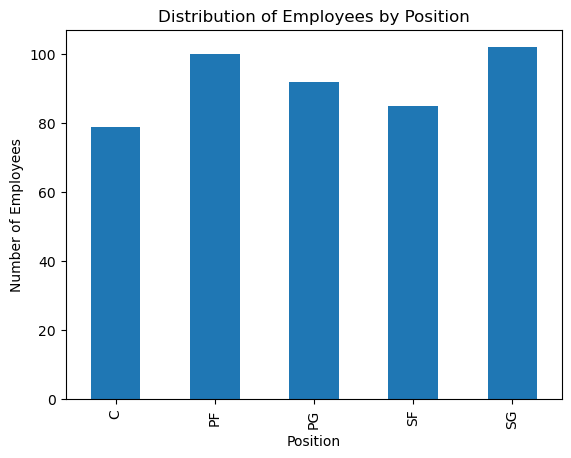

In [21]:
#Employees based on position
import matplotlib.pyplot as plt

position.plot(kind='bar')

plt.title("Distribution of Employees by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")

plt.show()

In [23]:
#Data Story:The results show the number of employees in each position.
#Some positions have a higher employee count than others, 
#indicating that these roles are more common in the organization. 
#This distribution helps identify the workforce composition across different job positions.

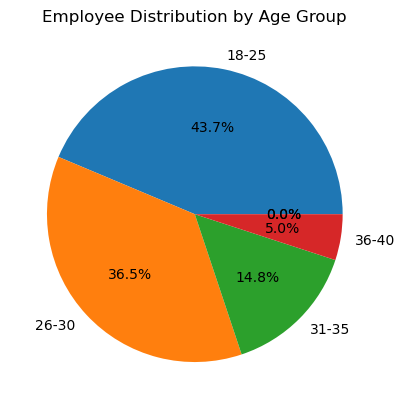

In [24]:
### Employee Distribution by Age Group
p.plot(kind='pie', autopct='%1.1f%%')

plt.title("Employee Distribution by Age Group")
plt.ylabel("")

plt.show()

In [ ]:
#Datastory:Most employees belong to the predominant age group ( 26–30 years), 
#suggesting a relatively young workforce.

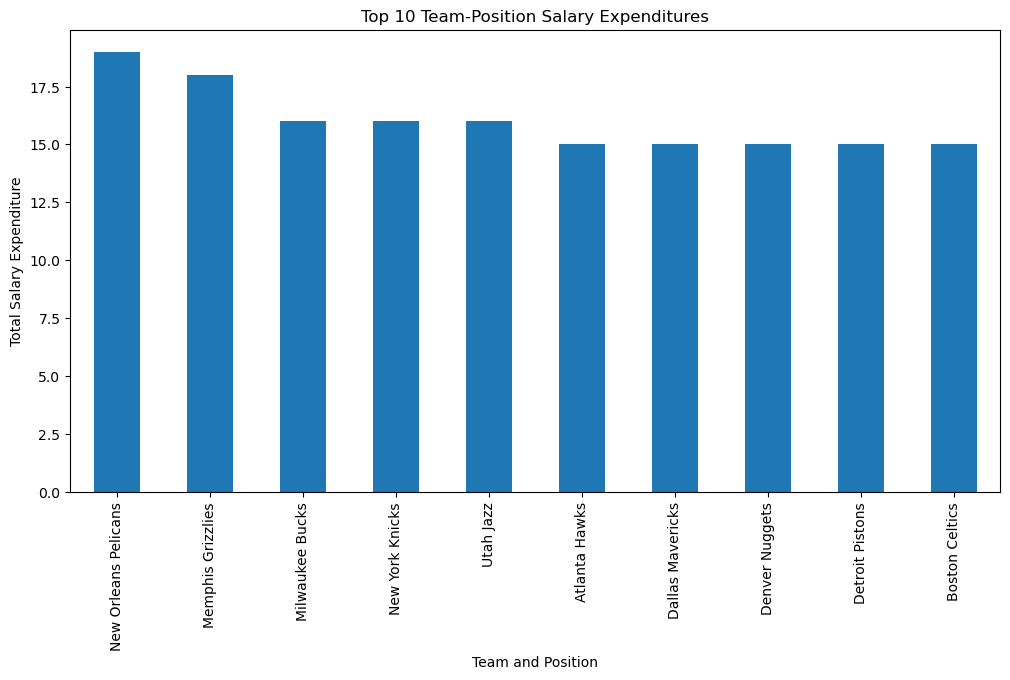

In [26]:
#4.eam-Position Salary Expenditures
import matplotlib.pyplot as plt
top10 = gdf.sort_values(ascending=False).head(10)
top10.plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Team-Position Salary Expenditures")
plt.xlabel("Team and Position")
plt.ylabel("Total Salary Expenditure")
plt.show()